# 树叶数据集训练
classify-leaves
```bash
(py310) λ ls
images/  sample_submission.csv  test.csv  train.csv
```

图像全部存储在images文件夹中，test.csv保存测试（验证）数据名，train.csv保存是训练数据




In [59]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import torchvision
from torchvision import datasets,transforms,models
from PIL import Image
import pandas as pd
from tqdm import tqdm
import time

In [60]:
# 读取train.csv test.csv文件，看看内部有什么？
# 根据列名，train.csv中两列数据，image label
DATA_DIR = './datasets/classify-leaves'
df_train = pd.read_csv('./datasets/classify-leaves/train.csv')
print(f"训练行数：{len(df_train)}")
print(f"训练列数：{len(df_train.columns)}")
print(f"训练列名:{df_train.columns.to_list()}")
print(f"训练前5行:{df_train.head()}")
print(df_train.describe())
print("="*60)
df_test = pd.read_csv('./datasets/classify-leaves/test.csv')
print(f"测试行数：{len(df_test)}")
print(f"测试列数：{len(df_test.columns)}")
print(f"测试列名:{df_test.columns.to_list()}")
print(f"测试前5行:{df_test.head()}")

训练行数：18353
训练列数：2
训练列名:['image', 'label']
训练前5行:          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera
               image             label
count          18353             18353
unique         18353               176
top     images/0.jpg  maclura_pomifera
freq               1               353
测试行数：8800
测试列数：1
测试列名:['image']
测试前5行:              image
0  images/18353.jpg
1  images/18354.jpg
2  images/18355.jpg
3  images/18356.jpg
4  images/18357.jpg


In [61]:
# 训练数据18353个，测试数据8800个，类别数？
class_counts = df_train['label'].value_counts()
class_counts_list = df_train['label'].value_counts().values.tolist()
class_counts_df = df_train['label'].value_counts().reset_index()
print(f"类别总数:{class_counts}")
print(f"类别总数类型:{type(class_counts)}")
print(f"类别总数类型df:{type(class_counts_df)}")
print(f"类别总数List:{class_counts_list}")

class_names = df_train['label'].value_counts().index.tolist()
print(f"类别名:{class_names}")


类别总数:label
maclura_pomifera            353
ulmus_rubra                 235
prunus_virginiana           223
acer_rubrum                 217
broussonettia_papyrifera    214
                           ... 
cedrus_deodara               58
ailanthus_altissima          58
crataegus_crus-galli         54
evodia_daniellii             53
juniperus_virginiana         51
Name: count, Length: 176, dtype: int64
类别总数类型:<class 'pandas.core.series.Series'>
类别总数类型df:<class 'pandas.core.frame.DataFrame'>
类别总数List:[353, 235, 223, 217, 214, 209, 193, 189, 176, 174, 173, 173, 170, 161, 156, 155, 154, 153, 145, 145, 145, 144, 143, 141, 141, 141, 138, 135, 130, 128, 127, 127, 124, 123, 122, 120, 119, 119, 115, 115, 112, 111, 111, 110, 109, 109, 108, 107, 107, 106, 105, 105, 105, 105, 105, 105, 105, 104, 104, 103, 103, 103, 102, 102, 101, 101, 101, 101, 101, 101, 101, 100, 100, 100, 99, 99, 99, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 98, 98, 97, 97, 96, 96, 95, 95, 95, 95, 94, 94, 94, 93, 93, 93, 93, 92, 89, 

C:\Users\shengchen\AppData\Local\Temp\ipykernel_52240\3975889793.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='类别名称', y='图片数量', palette='viridis')


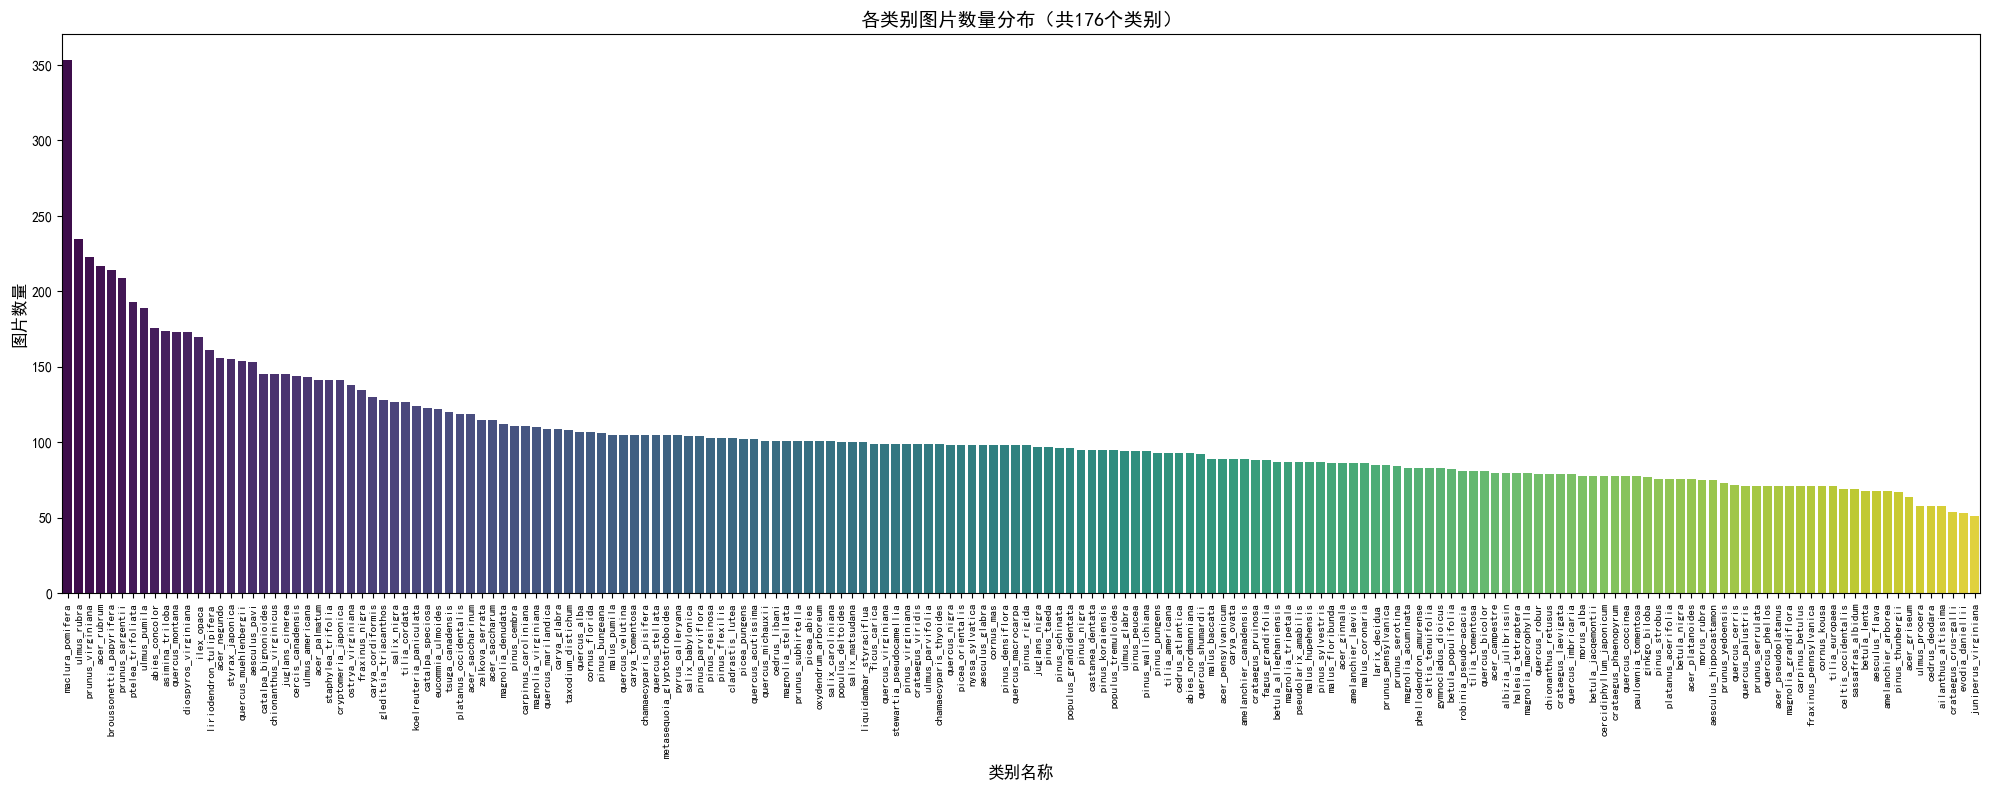

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# seaborn 需要DataFrame类型的数据
class_counts = df_train['label'].value_counts().reset_index() # 转换为DataFrame类型
class_counts.columns = ['类别名称', '图片数量']

# ============================================================
# 1. 基础柱状图（显示所有类别）
# ============================================================
plt.figure(figsize=(20, 8))
sns.barplot(data=class_counts, x='类别名称', y='图片数量', palette='viridis')
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('类别名称', fontsize=12)
plt.ylabel('图片数量', fontsize=12)
plt.title('各类别图片数量分布（共{}个类别）'.format(len(class_counts)), fontsize=14)
plt.tight_layout()
# plt.savefig('class_distribution_all.png', dpi=300, bbox_inches='tight')
plt.show()


In [63]:
# unique 获取该列不重复的唯一值，也就是类别,sorted 对获取到的唯一值进行排序，确保类别的顺序是固定的
df_class = sorted(df_train['label'].unique())
print(f"类别总数:{df_class}")
print(f"类别总数:{len(df_class)}")
df_class_to_idx = {v: k  for k, v in enumerate(df_class)}
print(f"df_class_to_idx:{df_class_to_idx}")
df_idx_to_class = {v: k for k, v in df_class_to_idx.items()}
print(f"df_idx_to_class:{df_idx_to_class}")


# 打印时加上类型信息
print(f"df_class_to_idx: {df_class_to_idx}")
print(f"  (键类型: {type(list(df_class_to_idx.keys())[0])})")
print(f"  (值类型: {type(list(df_class_to_idx.values())[0])})")
print()
print(f"df_idx_to_class: {df_idx_to_class}")
print(f"  (键类型: {type(list(df_idx_to_class.keys())[0])})")
print(f"  (值类型: {type(list(df_idx_to_class.values())[0])})")

print(f'df_class_to_idx[0] :{list(df_class_to_idx.items())[0]}')
print(f'df_idx_to_class[0] :{list(df_idx_to_class.items())[0]}')



类别总数:['abies_concolor', 'abies_nordmanniana', 'acer_campestre', 'acer_ginnala', 'acer_griseum', 'acer_negundo', 'acer_palmatum', 'acer_pensylvanicum', 'acer_platanoides', 'acer_pseudoplatanus', 'acer_rubrum', 'acer_saccharinum', 'acer_saccharum', 'aesculus_flava', 'aesculus_glabra', 'aesculus_hippocastamon', 'aesculus_pavi', 'ailanthus_altissima', 'albizia_julibrissin', 'amelanchier_arborea', 'amelanchier_canadensis', 'amelanchier_laevis', 'asimina_triloba', 'betula_alleghaniensis', 'betula_jacqemontii', 'betula_lenta', 'betula_nigra', 'betula_populifolia', 'broussonettia_papyrifera', 'carpinus_betulus', 'carpinus_caroliniana', 'carya_cordiformis', 'carya_glabra', 'carya_ovata', 'carya_tomentosa', 'castanea_dentata', 'catalpa_bignonioides', 'catalpa_speciosa', 'cedrus_atlantica', 'cedrus_deodara', 'cedrus_libani', 'celtis_occidentalis', 'celtis_tenuifolia', 'cercidiphyllum_japonicum', 'cercis_canadensis', 'chamaecyparis_pisifera', 'chamaecyparis_thyoides', 'chionanthus_retusus', 'chion

In [64]:
# 封装数据集
class LeafDataset(Dataset):
    def __init__(self, data_dir, mode='train', transform=None):
        """
        data_dir: 数据根目录
        mode: train/test
        transform: 数据预处理
        """
        self.data_dir = data_dir
        self.mode = mode
        self.transform = transform
        self.img_dir = data_dir

        if mode == 'train':
            csv_path = os.path.join(data_dir, "train.csv")
            self.df = pd.read_csv(csv_path)
            self.image_col = 'image'
            self.label_col = 'label'

            # 构建类别映射
            self.classes = sorted(self.df[self.label_col].unique())
            self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
            self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}
            self.num_classes = len(self.classes)
            print(f"Train: {len(self.df)} 张图片, {self.num_classes} 个类别")
        else:
            csv_path = os.path.join(data_dir, "test.csv")
            self.df = pd.read_csv(csv_path)
            self.image_col = 'image'
            self.num_classes = None
            print(f"Test: {len(self.df)} 张图片")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row[self.image_col]
        img_path = os.path.join(self.img_dir, img_name)
        
        # 加载图片
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"Warning: {img_path} not found")
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))
        
        # 数据增强
        if self.transform:
            image = self.transform(image)
        
        # 训练模式返回 (图片, 标签)，测试模式返回 (图片, 文件名)
        if self.mode == 'train':
            label = self.class_to_idx[row[self.label_col]]
            return image, label
        else:
            return image, img_name


train_transform  = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

batch_size = 64

train_data = LeafDataset(DATA_DIR,'train',train_transform)
test_data = LeafDataset(DATA_DIR,'test',test_transform)

train_loader = DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data,batch_size=batch_size,shuffle=False)

print(f"\n类别数: {train_data.num_classes}")
print(f"类别映射示例: {list(train_data.class_to_idx.items())[:5]}")

Train: 18353 张图片, 176 个类别
Test: 8800 张图片

类别数: 176
类别映射示例: [('abies_concolor', 0), ('abies_nordmanniana', 1), ('acer_campestre', 2), ('acer_ginnala', 3), ('acer_griseum', 4)]


In [65]:
# 创建模型
def creat_model(num_classes, pretrained=True):
    """创建AlexNet
    num_classes:类别
    pretrained:是否加载权重
    """
    if pretrained:
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    else:
        model = models.alexnet(weights=None)

    # 修改最后一层
    num_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_features,num_classes)
    # 如何冻结，如何修改？
    return model

model = creat_model(train_data.num_classes,pretrained=False)

print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [70]:
# 训练和验证
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计
        running_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test_predict(model, dataloader, device, idx_to_class):
    """测试函数：用于测试集（无标签）"""
    model.eval()
    predictions = []
    image_names = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Testing', leave=False)
        for images, names in pbar:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            image_names.extend(names)
    
    # 转换为类别名称
    pred_labels = [idx_to_class[p] for p in predictions]
    return image_names, pred_labels

In [71]:
lr = 1e-4
epochs = 10
batch_size =64 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device :{device}')
model = model.to(device)
# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# 训练记录
history = {
    'train_loss': [], 'train_acc': [],
    'epoch_time': []
}
best_acc = 0.0 
start_time = time.time()

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    
    # 训练
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # 更新学习率
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # 记录
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    epoch_time = time.time() - epoch_start
    history['epoch_time'].append(epoch_time)
    
    # 打印结果
    print(f"\nEpoch [{epoch:2d}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print(f"  Time: {epoch_time:.1f}s")
    print("-" * 50)

total_time = time.time() - start_time
print(f"\n 训练完成！总时间: {total_time/60:.1f} 分钟")      

device :cuda



Epoch [ 1/10]
  Train Loss: 2.8140, Train Acc: 24.81%
  LR: 0.000100
  Time: 46.4s
--------------------------------------------------



Epoch [ 2/10]
  Train Loss: 2.3771, Train Acc: 33.32%
  LR: 0.000100
  Time: 79.1s
--------------------------------------------------



Epoch [ 3/10]
  Train Loss: 2.0274, Train Acc: 41.31%
  LR: 0.000100
  Time: 78.4s
--------------------------------------------------



Epoch [ 4/10]
  Train Loss: 1.7726, Train Acc: 46.49%
  LR: 0.000100
  Time: 63.0s
--------------------------------------------------


...


Epoch [ 6/10]
  Train Loss: 1.3803, Train Acc: 56.92%
  LR: 0.000100
  Time: 59.8s
--------------------------------------------------



Epoch [ 7/10]
  Train Loss: 1.2537, Train Acc: 60.19%
  LR: 0.000100
  Time: 50.6s
--------------------------------------------------



Epoch [ 8/10]
  Train Loss: 1.1040, Train Acc: 64.67%
  LR: 0.000100
  Time: 149.2s
--------------------------------------------------



Epoch [ 9/10]
  Train Loss: 1.0155, Train Acc: 67.29%
  LR: 0.000100
  Time: 39.0s
--------------------------------------------------



Epoch [10/10]
  Train Loss: 0.9126, Train Acc: 69.68%
  LR: 0.000050
  Time: 113.5s
--------------------------------------------------

 训练完成！总时间: 12.2 分钟
